C:\Users\Vajeevan\AppData\Local\Temp\ipykernel_14292\3889213827.py:157: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.ravel(),256,[0,256])


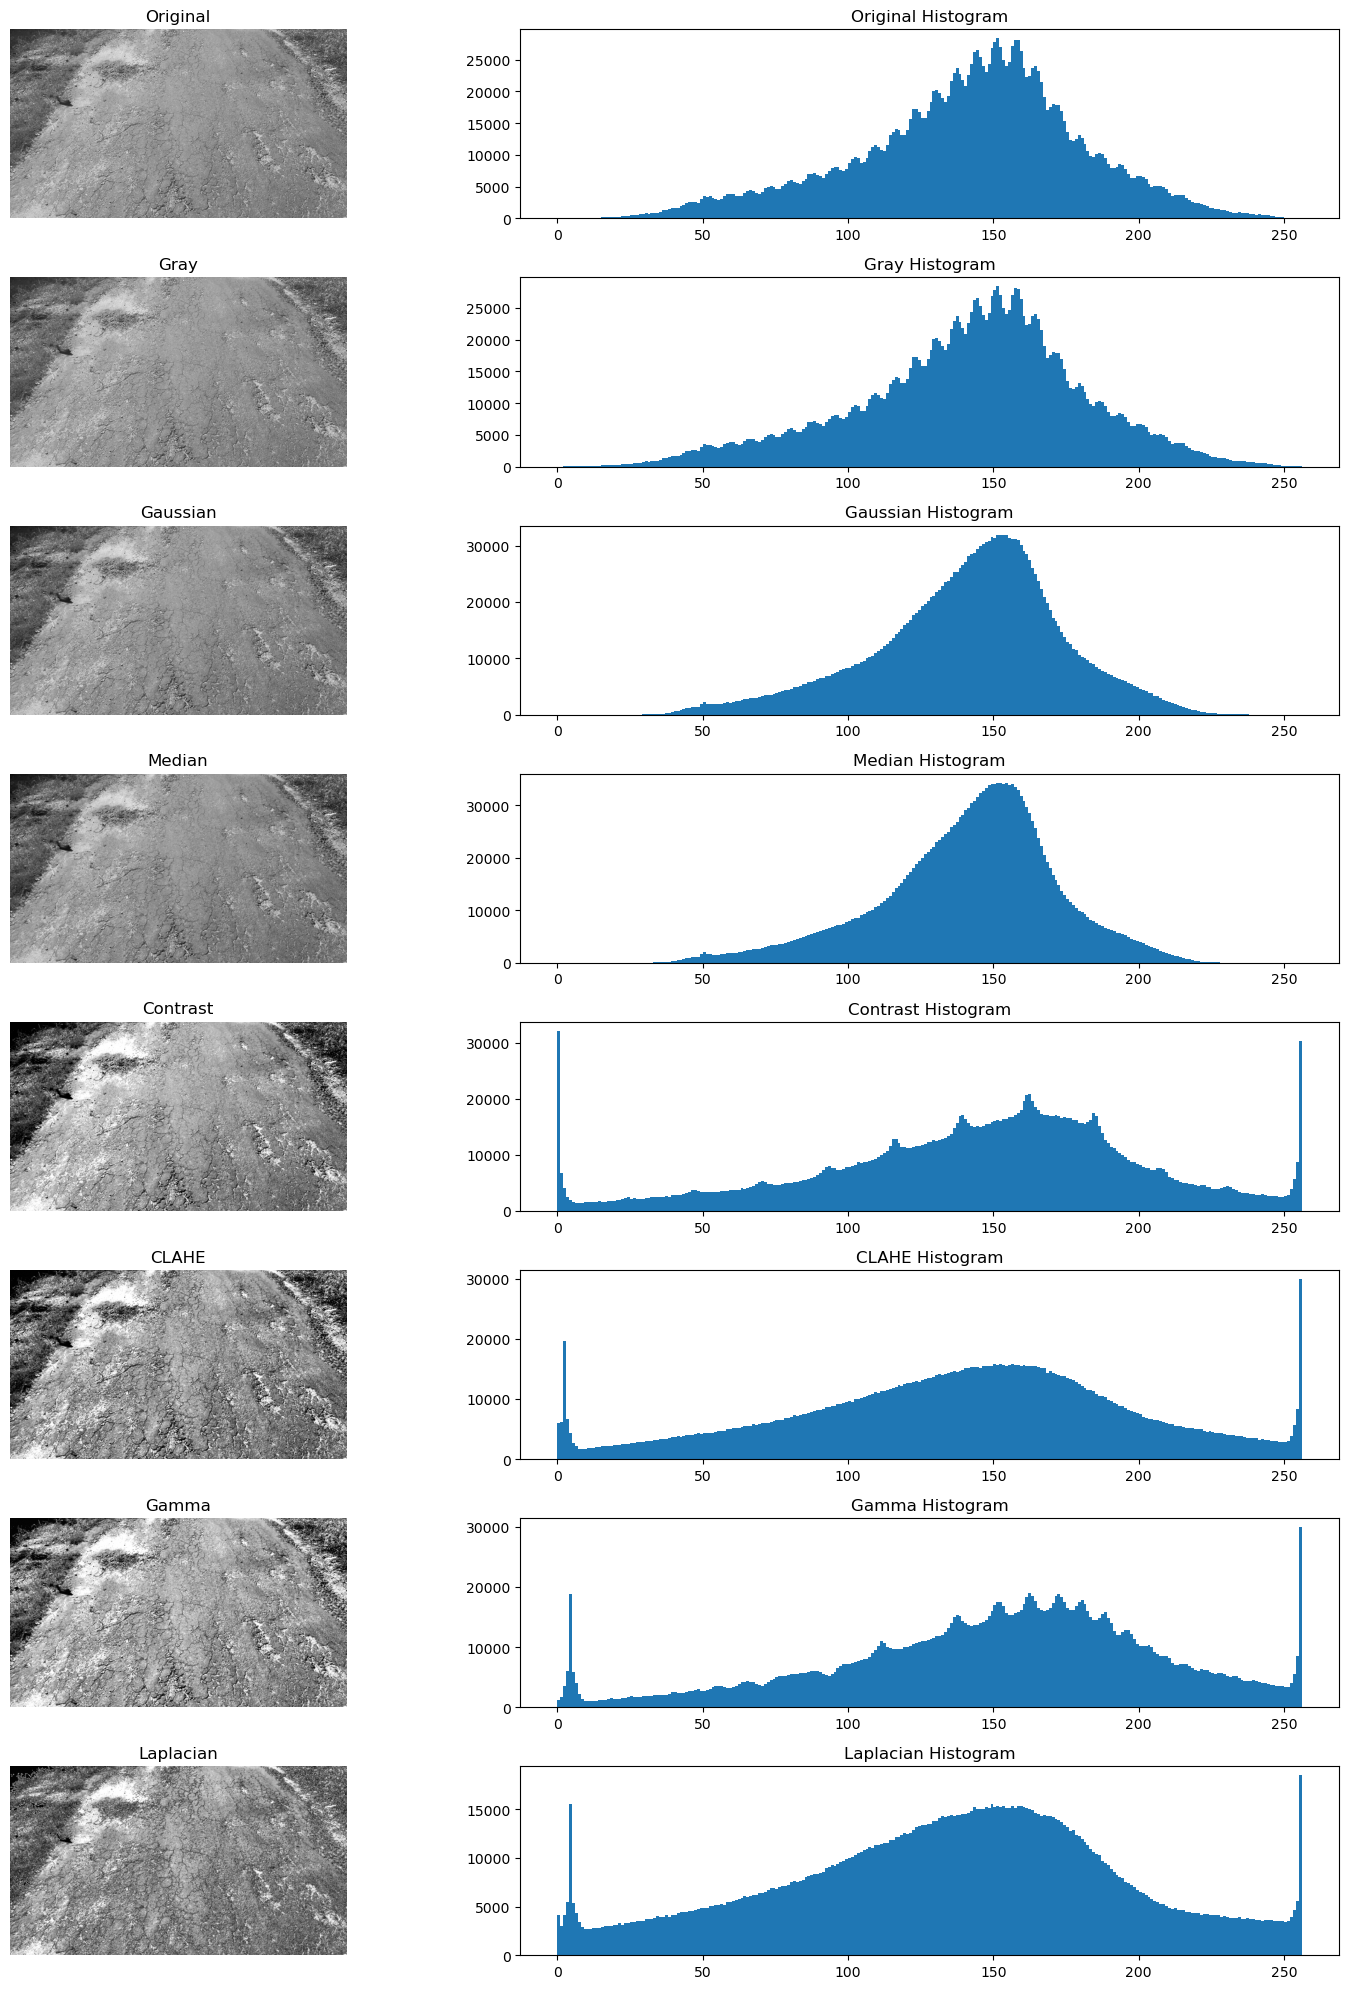


Quantitative Results Table
--------------------------------------------------------------------------
Stage      Mean       Std Dev    Entropy    Sharpness 
--------------------------------------------------------------------------
Gray       139.11     37.58      7.233      4415.74   
Gaussian   139.14     30.60      6.934      512.05    
Median     139.16     28.60      6.828      337.53    
Contrast   138.66     55.56      7.653      1375.79   
CLAHE      134.81     57.82      7.761      2172.82   
Gamma      147.05     55.50      7.690      1985.78   
laplacian  132.00     57.79      7.799      29161.82  
--------------------------------------------------------------------------
Done! 30 frames saved.


In [2]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def gamma_correction(img, gamma=1.2):
    invGamma = 1.0 / gamma
    table = np.array([(i / 255.0) ** invGamma * 255
                      for i in np.arange(256)]).astype("uint8")
    return cv2.LUT(img, table)

def calculate_entropy(img):
    hist = cv2.calcHist([img],[0],None,[256],[0,256])
    hist = hist.ravel()/hist.sum()
    hist = hist[hist>0]
    entropy = -np.sum(hist*np.log2(hist))
    return entropy

def calculate_sharpness(img):
    lap = cv2.Laplacian(img, cv2.CV_64F)
    return lap.var()


def calculate_metrics(folder):
    files = sorted(os.listdir(folder))

    mean_list = []
    std_list = []
    entropy_list = []
    sharpness_list = []

    for f in files:
        path = os.path.join(folder,f)
        img = cv2.imread(path,0)

        mean_list.append(np.mean(img))
        std_list.append(np.std(img))
        entropy_list.append(calculate_entropy(img))
        sharpness_list.append(calculate_sharpness(img))

    return (
        np.mean(mean_list),
        np.mean(std_list),
        np.mean(entropy_list),
        np.mean(sharpness_list)
    )




video_path = "road_1080p.mp4"

original_folder = "original_frames"
gray_folder = "gray_frames"
gaussian_folder ="gaussian_frames"
median_folder="median_folder"
contrast_folder = "contrast_frames"
clahe_folder="clahe_frames"
gamma_folder ="gamma_frames"
lap_folder="lap_frames"

os.makedirs(original_folder, exist_ok=True)
os.makedirs(gray_folder, exist_ok=True)
os.makedirs(gaussian_folder, exist_ok=True)
os.makedirs(median_folder, exist_ok=True)
os.makedirs(contrast_folder, exist_ok=True)
os.makedirs(clahe_folder, exist_ok=True)
os.makedirs(gamma_folder, exist_ok=True)
os.makedirs(lap_folder, exist_ok=True)

cap = cv2.VideoCapture(video_path)

frame_count = 1
f=0

while True:
    ret, frame = cap.read()

    if not ret:
        break 
    if frame_count % 41 == 0:
        frame_name = f"{original_folder}/original_frame_{frame_count:05d}.jpg"
        cv2.imwrite(frame_name, frame)

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gaussian = cv2.GaussianBlur(gray, (3, 3), 0)
        median = cv2.medianBlur(gaussian, 3)

        p2, p98 = np.percentile(median, (2, 98))
        contrast = np.clip(median, p2, p98)
        contrast = ((contrast - p2) / (p98 - p2) * 255).astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        clahe_enhanced = clahe.apply(contrast)

        gamma_img = gamma_correction(clahe_enhanced, 1.2)
        lap = cv2.Laplacian(gamma_img, cv2.CV_64F)
        lap = cv2.convertScaleAbs(lap)
        lap = gamma_img - lap

        frame_name = f"{gray_folder}/gray_frame_{frame_count:05d}.jpg"
        cv2.imwrite(frame_name, gray)
        
        frame_name = f"{gaussian_folder}/gaussian_frame_{frame_count:05d}.jpg"
        cv2.imwrite(frame_name, gaussian)

        frame_name = f"{median_folder}/median_frame_{frame_count:05d}.jpg"
        cv2.imwrite(frame_name, median)

        frame_name = f"{contrast_folder}/contrast_frame_{frame_count:05d}.jpg"
        cv2.imwrite(frame_name, contrast)

        frame_name = f"{clahe_folder}/clahe_frame_{frame_count:05d}.jpg"
        cv2.imwrite(frame_name, clahe_enhanced)

        frame_name = f"{gamma_folder}/gammma_frame_{frame_count:05d}.jpg"
        cv2.imwrite(frame_name, gamma_img)

        frame_name = f"{lap_folder}/lap_frame_{frame_count:05d}.jpg"
        cv2.imwrite(frame_name, lap)
        
        f += 1

    frame_count += 1

cap.release()

#to print images and histograms
folders = [
    ("Original", original_folder),
    ("Gray", gray_folder),
    ("Gaussian", gaussian_folder),
    ("Median", median_folder),
    ("Contrast", contrast_folder),
    ("CLAHE", clahe_folder),
    ("Gamma", gamma_folder),
    ("Laplacian", lap_folder)
]

images = []

for name, folder in folders:
    files = sorted(os.listdir(folder))
    first_img_path = os.path.join(folder, files[0])
    img = cv2.imread(first_img_path, 0)
    images.append((name, img))

plt.figure(figsize=(16,20))

for i, (name, img) in enumerate(images):

    plt.subplot(8,2,2*i+1)
    plt.imshow(img, cmap='gray')
    plt.title(name)
    plt.axis("off")

    plt.subplot(8,2,2*i+2)
    plt.hist(img.ravel(),256,[0,256])
    plt.title(name + " Histogram")

plt.tight_layout()
plt.show()

#to print the chart
stages = [
    ("Gray", gray_folder),
    ("Gaussian", gaussian_folder),
    ("Median", median_folder),
    ("Contrast", contrast_folder),
    ("CLAHE", clahe_folder),
    ("Gamma", gamma_folder),
    ("laplacian", lap_folder)
]

print("\nQuantitative Results Table")
print("--------------------------------------------------------------------------")
print(f"{'Stage':<10} {'Mean':<10} {'Std Dev':<10} {'Entropy':<10} {'Sharpness':<10}")
print("--------------------------------------------------------------------------")

for name, folder in stages:
    mean, std, ent, sharp = calculate_metrics(folder)

    print(f"{name:<10} {mean:<10.2f} {std:<10.2f} {ent:<10.3f} {sharp:<10.2f}")

print("--------------------------------------------------------------------------")

#to show the first input and final output images 
input_img=cv2.imread("gray_frames\gray_frame_00041.jpg",0)
output_img=cv2.imread("lap_frames\lap_frame_00041.jpg",0)
cv2.namedWindow("input", cv2.WINDOW_NORMAL)
cv2.resizeWindow("input", 800, 500)
cv2.namedWindow("output", cv2.WINDOW_NORMAL)
cv2.resizeWindow("output", 800, 500)
cv2.imshow("input",input_img)
cv2.imshow("output",output_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

print(f"Done! {f} frames saved.")